# Week 4 · Day 4 — Model Tuning, Regularization & Reproducible Pipelines

**Dataset:** UCI Adult (Census Income) — predict whether income >50K/year  
**Primary metric:** F1 (positive class = >50K), secondary: ROC AUC

---

## How to Reproduce Results

```bash
pip install scikit-learn pandas numpy matplotlib scipy joblib
jupyter nbconvert --to notebook --execute --inplace code.ipynb
```

**Reproducibility controls:**
- `SEED = 42` passed to every estimator, search, and split
- `numpy.random.seed(SEED)` set at startup
- Same `train_test_split(test_size=0.20, random_state=42, stratify=y)` as Days 1-3
- Library versions printed in the first code cell

---
## Task 1 — Setup, Reproducibility & Fully Reproducible Pipeline

In [1]:
import json, time, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    f1_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, accuracy_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)
from scipy.stats import randint, loguniform

import sklearn, scipy, matplotlib
print('Library versions:')
print(f'  scikit-learn : {sklearn.__version__}')
print(f'  pandas       : {pd.__version__}')
print(f'  numpy        : {np.__version__}')
print(f'  scipy        : {scipy.__version__}')
print(f'  matplotlib   : {matplotlib.__version__}')
print(f'  joblib       : {joblib.__version__}')
print(f'\nGlobal random seed: {SEED}')

Library versions:
  scikit-learn : 1.8.0
  pandas       : 3.0.1
  numpy        : 2.4.2
  scipy        : 1.17.0
  matplotlib   : 3.10.8
  joblib       : 1.5.3

Global random seed: 42


In [2]:
print('Loading Adult dataset...')
adult = fetch_openml('adult', version=2, as_frame=True)
df_raw = adult.frame.copy()
df_raw = df_raw.replace('?', np.nan)

y     = (df_raw['class'].astype(str).str.strip() == '>50K').astype(int)
X_raw = df_raw.drop(columns=['class'])

# Identical stratified split to Days 1-3
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Positive rate (train): {y_train.mean():.4f}')
print(f'Positive rate (test) : {y_test.mean():.4f}')

Loading Adult dataset...


Train: (39073, 14)  |  Test: (9769, 14)
Positive rate (train): 0.2393
Positive rate (test) : 0.2393


In [3]:
# ============================================================
# FEATURE ENGINEERING (identical to Day 3 -- no leakage)
# Applied via FunctionTransformer so it runs per CV fold.
# ============================================================
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    """Add 7 engineered features from Day 3. No target-encoding."""
    X = X.copy()
    age   = pd.to_numeric(X['age'],            errors='coerce').fillna(0)
    hours = pd.to_numeric(X['hours-per-week'], errors='coerce').fillna(40)
    edu   = pd.to_numeric(X['education-num'],  errors='coerce').fillna(0)
    cg    = pd.to_numeric(X['capital-gain'],   errors='coerce').fillna(0)
    cl    = pd.to_numeric(X['capital-loss'],   errors='coerce').fillna(0)

    X['age_bucket']            = pd.cut(age,   bins=[0,30,45,60,120],
                                         labels=['young','mid_career','senior','late_career'],
                                         right=False).astype(str)
    X['hours_bin']             = pd.cut(hours, bins=[0,35,45,60,100],
                                         labels=['part_time','standard','overtime','extreme'],
                                         right=False).astype(str)
    X['has_capital_gain']      = (cg > 0).astype(int)
    X['log_capital_gain']      = np.log1p(cg)
    X['higher_education']      = (edu >= 13).astype(int)  # Bachelors threshold
    X['edu_hours_interaction'] = edu * hours
    X['log_capital_loss']      = np.log1p(cl)
    return X

# fnlwgt and education dropped (see Day 2/3 justification)
NUMERIC_BASE     = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
NUMERIC_ENG      = ['has_capital_gain', 'log_capital_gain', 'higher_education',
                    'edu_hours_interaction', 'log_capital_loss']
CATEGORICAL_BASE = ['workclass', 'marital-status', 'occupation', 'relationship',
                    'race', 'sex', 'native-country']
CATEGORICAL_ENG  = ['age_bucket', 'hours_bin']

ALL_NUMERIC     = NUMERIC_BASE + NUMERIC_ENG
ALL_CATEGORICAL = CATEGORICAL_BASE + CATEGORICAL_ENG

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     ALL_NUMERIC),
    ('cat', categorical_transformer, ALL_CATEGORICAL)
], remainder='drop')

eng_transformer = FunctionTransformer(engineer_features, validate=False)

def make_pipeline(estimator):
    """Factory: engineer -> preprocess -> classify."""
    return Pipeline([
        ('engineer',     eng_transformer),
        ('preprocessor', preprocessor),
        ('classifier',   estimator)
    ])

print('Reproducible pipeline factory ready.')
print(f'  Numeric   ({len(ALL_NUMERIC)}): {ALL_NUMERIC}')
print(f'  Categoric ({len(ALL_CATEGORICAL)}): {ALL_CATEGORICAL}')

Reproducible pipeline factory ready.
  Numeric   (10): ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'log_capital_gain', 'higher_education', 'edu_hours_interaction', 'log_capital_loss']
  Categoric (9): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bin']


---
## Task 2 — Hyperparameter Search (RandomizedSearchCV)

Three models tuned with **RandomizedSearchCV**, **StratifiedKFold(k=5)**, optimising **F1**.  
Budget: LR n_iter=40 (fast), RF n_iter=20 (RF is compute-heavy), HGB n_iter=40.

In [4]:
cv_inner  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scorer = make_scorer(f1_score, zero_division=0)

# --- 2a. Logistic Regression ---
# C: inverse regularisation -- small C = strong L2 regularisation
# class_weight='balanced': up-weights minority class to improve recall
# penalty='l2', solver='lbfgs': standard stable combination
lr_param_dist = {
    'classifier__C'           : loguniform(1e-3, 10),
    'classifier__penalty'     : ['l2'],
    'classifier__solver'      : ['lbfgs'],
    'classifier__max_iter'    : [500, 1000, 2000],
    'classifier__class_weight': ['balanced'],
}
lr_pipeline = make_pipeline(LogisticRegression(random_state=SEED))

print('Searching Logistic Regression (n_iter=40)...')
t0 = time.time()
lr_search = RandomizedSearchCV(
    lr_pipeline, lr_param_dist,
    n_iter=40, cv=cv_inner, scoring=f1_scorer,
    n_jobs=-1, random_state=SEED, verbose=0
)
lr_search.fit(X_train_raw, y_train)
print(f'  Best CV F1: {lr_search.best_score_:.4f}  | Time: {time.time()-t0:.1f}s')
print(f'  Best params: {lr_search.best_params_}')

Searching Logistic Regression (n_iter=40)...


  Best CV F1: 0.6889  | Time: 72.5s
  Best params: {'classifier__C': np.float64(0.2223333760592037), 'classifier__class_weight': 'balanced', 'classifier__max_iter': 500, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


In [5]:
# --- 2b. Random Forest ---
# n_estimators: kept small (50-200) to stay within time budget
# max_depth: key variance control -- None allows full growth (overfits)
# min_samples_leaf: regularises by requiring minimum samples per leaf
# max_features: 'sqrt' is standard (sqrt of total features per split)
# NOTE: n_jobs=1 on outer search to avoid nested parallelism on Windows
#       RF itself uses n_jobs=-1 for tree-level parallelism
rf_param_dist = {
    'classifier__n_estimators'   : [50, 100, 150, 200],
    'classifier__max_depth'      : [None, 8, 12, 20],
    'classifier__min_samples_leaf': randint(1, 15),
    'classifier__max_features'   : ['sqrt', 'log2'],
    'classifier__class_weight'   : ['balanced', 'balanced_subsample'],
}
rf_pipeline = make_pipeline(
    RandomForestClassifier(random_state=SEED, n_jobs=-1)
)

print('Searching Random Forest (n_iter=20)...')
t0 = time.time()
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist,
    n_iter=20, cv=cv_inner, scoring=f1_scorer,
    n_jobs=1, random_state=SEED, verbose=0
)
rf_search.fit(X_train_raw, y_train)
print(f'  Best CV F1: {rf_search.best_score_:.4f}  | Time: {time.time()-t0:.1f}s')
print(f'  Best params: {rf_search.best_params_}')

Searching Random Forest (n_iter=20)...


  Best CV F1: 0.6988  | Time: 204.0s
  Best params: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}


In [6]:
# --- 2c. HistGradientBoosting ---
# learning_rate: step size; lower = slower convergence but better generalisation
# max_iter: number of boosting rounds (more rounds + lower lr = better)
# max_leaf_nodes: primary complexity control (replaces max_depth for HGB)
# l2_regularization: shrinkage on leaf weights -- main regulariser
# min_samples_leaf: min samples to form a leaf
hgb_param_dist = {
    'classifier__learning_rate'    : loguniform(0.02, 0.3),
    'classifier__max_iter'         : randint(80, 300),
    'classifier__max_leaf_nodes'   : randint(15, 63),
    'classifier__l2_regularization': loguniform(1e-4, 1.0),
    'classifier__min_samples_leaf' : randint(5, 40),
    'classifier__class_weight'     : ['balanced'],
}
hgb_pipeline = make_pipeline(
    HistGradientBoostingClassifier(random_state=SEED)
)

print('Searching HistGradientBoosting (n_iter=40)...')
t0 = time.time()
hgb_search = RandomizedSearchCV(
    hgb_pipeline, hgb_param_dist,
    n_iter=40, cv=cv_inner, scoring=f1_scorer,
    n_jobs=-1, random_state=SEED, verbose=0
)
hgb_search.fit(X_train_raw, y_train)
print(f'  Best CV F1: {hgb_search.best_score_:.4f}  | Time: {time.time()-t0:.1f}s')
print(f'  Best params: {hgb_search.best_params_}')

Searching HistGradientBoosting (n_iter=40)...


  Best CV F1: 0.7132  | Time: 314.2s
  Best params: {'classifier__class_weight': 'balanced', 'classifier__l2_regularization': np.float64(0.7261414516028828), 'classifier__learning_rate': np.float64(0.1035041273903399), 'classifier__max_iter': 120, 'classifier__max_leaf_nodes': 43, 'classifier__min_samples_leaf': 19}


In [7]:
search_summary = pd.DataFrame([
    {'Model': 'Logistic Regression',  'n_iter': 40, 'Best CV F1': round(lr_search.best_score_,  4)},
    {'Model': 'Random Forest',        'n_iter': 20, 'Best CV F1': round(rf_search.best_score_,  4)},
    {'Model': 'HistGradientBoosting', 'n_iter': 40, 'Best CV F1': round(hgb_search.best_score_, 4)},
])
print('=== Hyperparameter Search Summary (StratifiedKFold k=5, metric=F1) ===')
print(search_summary.to_string(index=False))
print(f'\nLR  best params : {lr_search.best_params_}')
print(f'RF  best params : {rf_search.best_params_}')
print(f'HGB best params : {hgb_search.best_params_}')

=== Hyperparameter Search Summary (StratifiedKFold k=5, metric=F1) ===
               Model  n_iter  Best CV F1
 Logistic Regression      40      0.6889
       Random Forest      20      0.6988
HistGradientBoosting      40      0.7132

LR  best params : {'classifier__C': np.float64(0.2223333760592037), 'classifier__class_weight': 'balanced', 'classifier__max_iter': 500, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
RF  best params : {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
HGB best params : {'classifier__class_weight': 'balanced', 'classifier__l2_regularization': np.float64(0.7261414516028828), 'classifier__learning_rate': np.float64(0.1035041273903399), 'classifier__max_iter': 120, 'classifier__max_leaf_nodes': 43, 'classifier__min_samples_leaf': 19}


---
## Task 3 — Diagnose Overfitting / Underfitting

**Learning curves** plot train vs. val F1 across training sizes (3-fold CV to save time).  
**Both low** = high bias (underfitting). **Large gap** = high variance (overfitting).

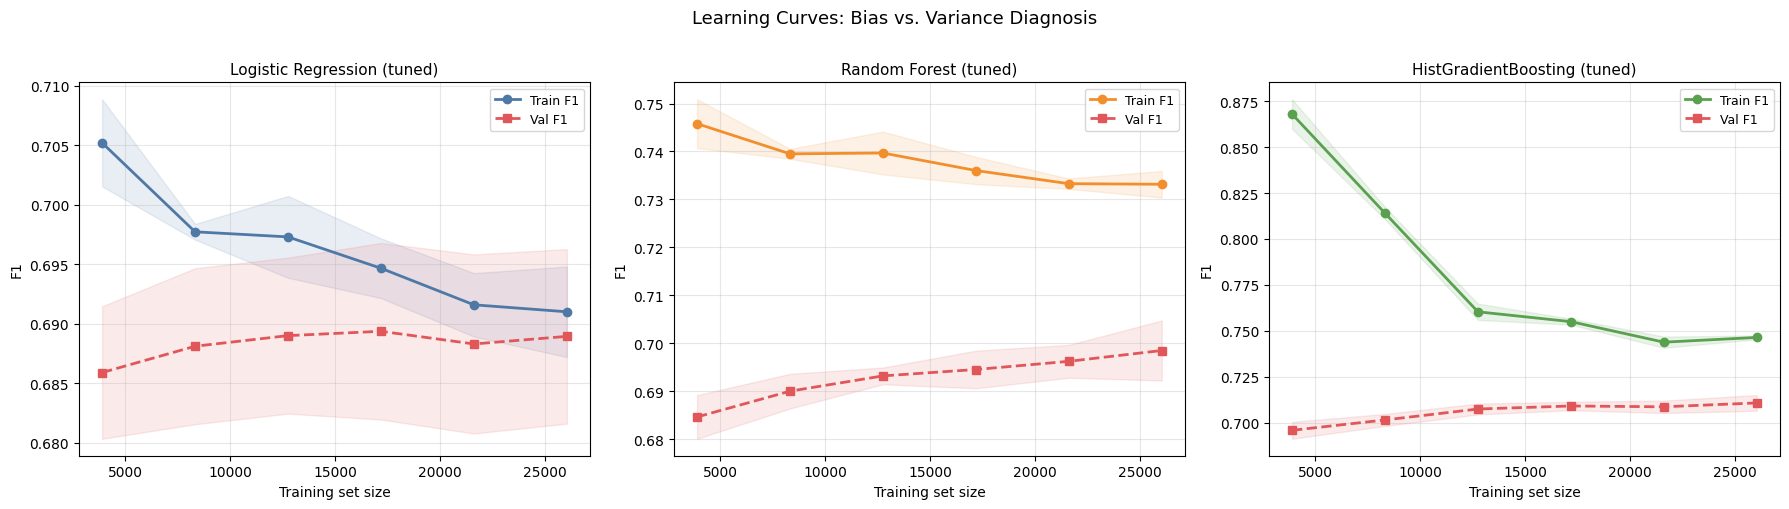

In [8]:
def plot_learning_curve(estimator, title, X, y, cv, ax, color='#4e79a7'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.15, 1.0, 6),
        cv=cv, scoring='f1', n_jobs=-1
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)
    ax.plot(train_sizes, tm, 'o-', color=color, label='Train F1', lw=2)
    ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.12, color=color)
    ax.plot(train_sizes, vm, 's--', color='#e15759', label='Val F1', lw=2)
    ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.12, color='#e15759')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('F1')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Use 3-fold CV for learning curves (reduces compute)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_learning_curve(lr_search.best_estimator_,  'Logistic Regression (tuned)',  X_train_raw, y_train, cv3, axes[0], '#4e79a7')
plot_learning_curve(rf_search.best_estimator_,  'Random Forest (tuned)',        X_train_raw, y_train, cv3, axes[1], '#f28e2b')
plot_learning_curve(hgb_search.best_estimator_, 'HistGradientBoosting (tuned)', X_train_raw, y_train, cv3, axes[2], '#59a14f')
plt.suptitle('Learning Curves: Bias vs. Variance Diagnosis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

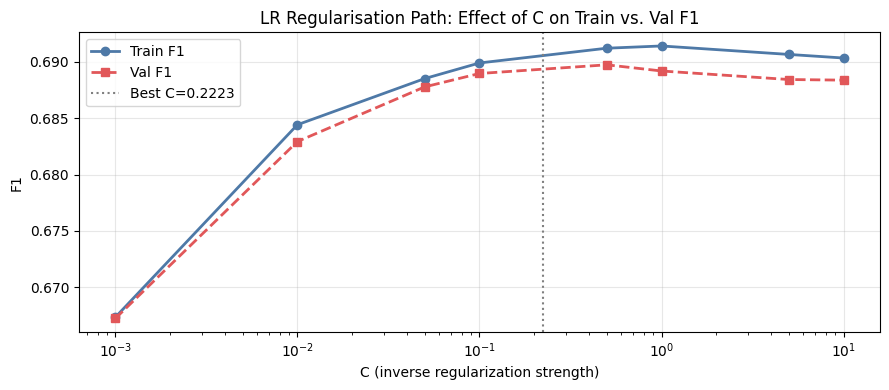


Interpretation:
  * Low C (strong L2) -> underfitting: both train and val F1 low (high bias).
  * High C (weak L2)  -> overfitting: train F1 rises, val F1 plateaus/drops.
  * Optimal C at the val-F1 peak; best C from search is marked with dotted line.
  Fix for underfitting: raise C. Fix for overfitting: lower C or get more data.



In [9]:
# 3b. Effect of C on Logistic Regression (regularisation path)
C_values    = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
lr_train_f1 = []
lr_val_f1   = []

for C in C_values:
    pipe = make_pipeline(
        LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                           max_iter=1000, random_state=SEED, class_weight='balanced')
    )
    tr_s, va_s = [], []
    for tr_idx, va_idx in cv3.split(X_train_raw, y_train):
        X_tr = X_train_raw.iloc[tr_idx]; X_va = X_train_raw.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx];     y_va = y_train.iloc[va_idx]
        pipe.fit(X_tr, y_tr)
        tr_s.append(f1_score(y_tr, pipe.predict(X_tr), zero_division=0))
        va_s.append(f1_score(y_va, pipe.predict(X_va), zero_division=0))
    lr_train_f1.append(np.mean(tr_s))
    lr_val_f1.append(np.mean(va_s))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_values, lr_train_f1, 'o-', color='#4e79a7', lw=2, label='Train F1')
ax.semilogx(C_values, lr_val_f1,   's--', color='#e15759', lw=2, label='Val F1')
best_C = lr_search.best_params_['classifier__C']
ax.axvline(best_C, color='grey', linestyle=':', label=f'Best C={best_C:.4f}')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('F1')
ax.set_title('LR Regularisation Path: Effect of C on Train vs. Val F1')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("""
Interpretation:
  * Low C (strong L2) -> underfitting: both train and val F1 low (high bias).
  * High C (weak L2)  -> overfitting: train F1 rises, val F1 plateaus/drops.
  * Optimal C at the val-F1 peak; best C from search is marked with dotted line.
  Fix for underfitting: raise C. Fix for overfitting: lower C or get more data.
""")

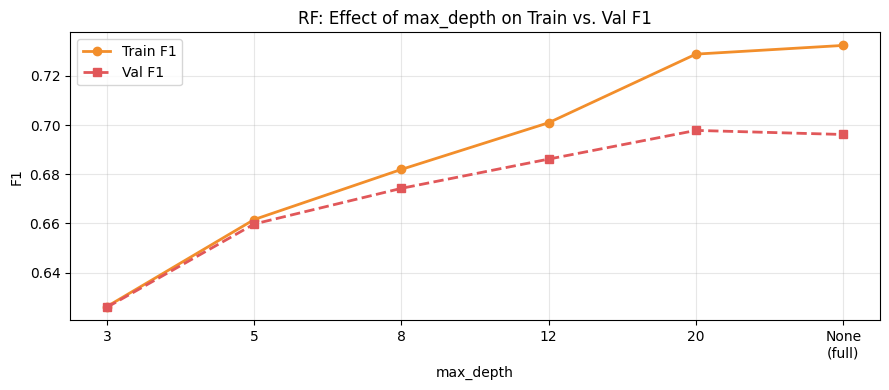


Interpretation:
  * Shallow trees (depth 3-5): underfitting -- both curves low (high bias).
  * Full trees (None): overfitting -- train F1 near 1.0, val gap widens.
  * Optimal: depth 10-20 on Adult (balances complexity vs. generalisation).
  Fix: lower max_depth or raise min_samples_leaf to reduce variance.



In [10]:
# 3c. Effect of max_depth on Random Forest
depth_values = [3, 5, 8, 12, 20, None]
rf_train_f1  = []
rf_val_f1    = []

# Carry all best RF params except max_depth
best_rf_extra = {k.replace('classifier__', ''): v
                 for k, v in rf_search.best_params_.items()
                 if k != 'classifier__max_depth'}
# Use small n_estimators for speed in this diagnostic
best_rf_extra['n_estimators'] = 80

for depth in depth_values:
    pipe = make_pipeline(
        RandomForestClassifier(max_depth=depth, random_state=SEED, n_jobs=-1, **best_rf_extra)
    )
    tr_s, va_s = [], []
    for tr_idx, va_idx in cv3.split(X_train_raw, y_train):
        X_tr = X_train_raw.iloc[tr_idx]; X_va = X_train_raw.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx];     y_va = y_train.iloc[va_idx]
        pipe.fit(X_tr, y_tr)
        tr_s.append(f1_score(y_tr, pipe.predict(X_tr), zero_division=0))
        va_s.append(f1_score(y_va, pipe.predict(X_va), zero_division=0))
    rf_train_f1.append(np.mean(tr_s))
    rf_val_f1.append(np.mean(va_s))

labels = [str(d) if d else 'None\n(full)' for d in depth_values]
x = range(len(depth_values))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, rf_train_f1, 'o-', color='#f28e2b', lw=2, label='Train F1')
ax.plot(x, rf_val_f1,   's--', color='#e15759', lw=2, label='Val F1')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_xlabel('max_depth'); ax.set_ylabel('F1')
ax.set_title('RF: Effect of max_depth on Train vs. Val F1')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("""
Interpretation:
  * Shallow trees (depth 3-5): underfitting -- both curves low (high bias).
  * Full trees (None): overfitting -- train F1 near 1.0, val gap widens.
  * Optimal: depth 10-20 on Adult (balances complexity vs. generalisation).
  Fix: lower max_depth or raise min_samples_leaf to reduce variance.
""")

---
## Task 4 — Probability Calibration & Threshold Selection

In [11]:
# Carve out 20% of training set as calibration holdout
X_train_fit, X_cal, y_train_fit, y_cal = train_test_split(
    X_train_raw, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

best_lr  = lr_search.best_estimator_
best_rf  = rf_search.best_estimator_
best_hgb = hgb_search.best_estimator_

models_dict = {
    'Logistic Regression' : best_lr,
    'Random Forest'       : best_rf,
    'HistGradientBoosting': best_hgb,
}

for name, pipe in models_dict.items():
    pipe.fit(X_train_fit, y_train_fit)
    print(f'Fitted {name} on train-fit subset')

Fitted Logistic Regression on train-fit subset


Fitted Random Forest on train-fit subset


Fitted HistGradientBoosting on train-fit subset


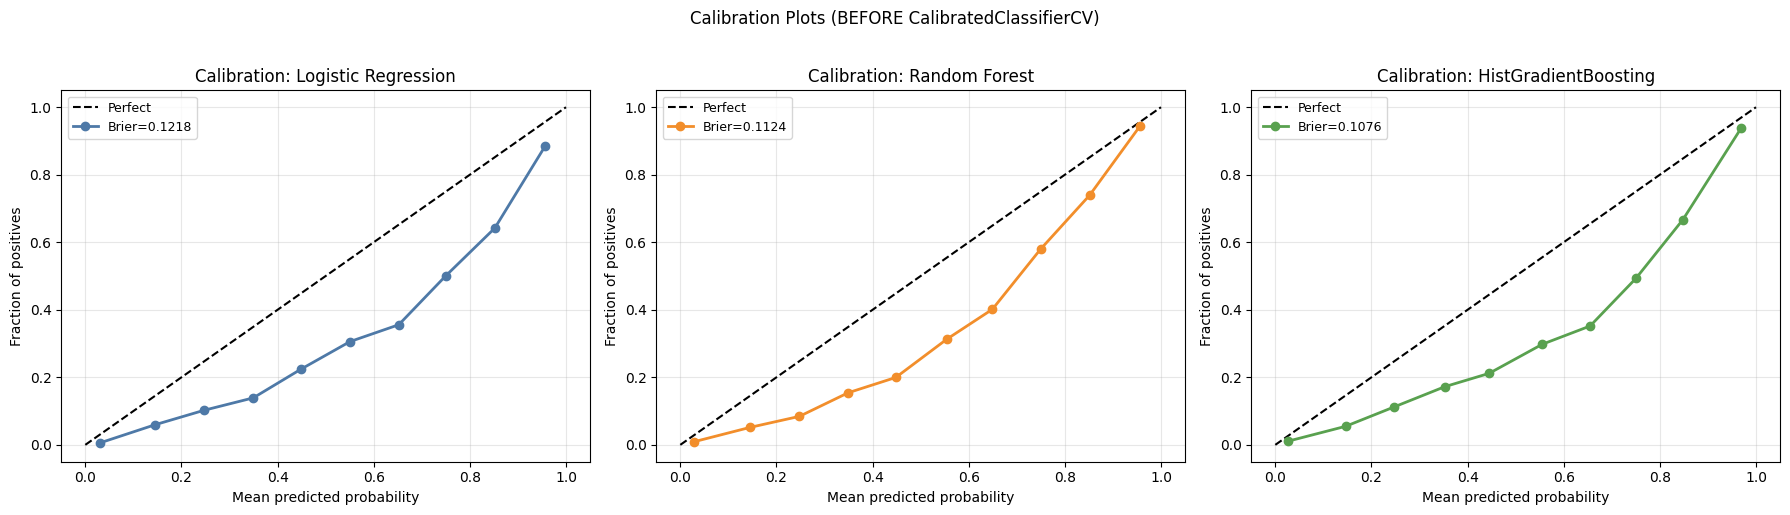

Brier scores before calibration (lower = better):
  Logistic Regression      : 0.1218
  Random Forest            : 0.1124
  HistGradientBoosting     : 0.1076


In [12]:
# Calibration curves BEFORE correction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4e79a7', '#f28e2b', '#59a14f']
brier_before = {}

for ax, (name, pipe), color in zip(axes, models_dict.items(), colors):
    prob_pos = pipe.predict_proba(X_cal)[:, 1]
    brier    = brier_score_loss(y_cal, prob_pos)
    brier_before[name] = brier
    frac_pos, mean_pred = calibration_curve(y_cal, prob_pos, n_bins=10, strategy='uniform')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, label=f'Brier={brier:.4f}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration: {name}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Calibration Plots (BEFORE CalibratedClassifierCV)', y=1.02)
plt.tight_layout(); plt.show()
print('Brier scores before calibration (lower = better):')
for n, b in brier_before.items():
    print(f'  {n:25s}: {b:.4f}')

In [13]:
# Apply CalibratedClassifierCV (isotonic, cv=5) on full training set
for name, pipe in models_dict.items():
    pipe.fit(X_train_raw, y_train)

calibrated_models = {}
brier_after = {}

for name, pipe in models_dict.items():
    cal_pipe = CalibratedClassifierCV(pipe, cv=5, method='isotonic')
    cal_pipe.fit(X_train_raw, y_train)
    calibrated_models[name] = cal_pipe
    prob_cal = cal_pipe.predict_proba(X_cal)[:, 1]
    brier_after[name] = brier_score_loss(y_cal, prob_cal)

print('Brier scores BEFORE vs. AFTER isotonic calibration:')
for name in models_dict:
    delta = brier_after[name] - brier_before[name]
    tag   = 'improved' if delta < 0 else 'worsened'
    print(f'  {name:25s}: Before={brier_before[name]:.4f}  After={brier_after[name]:.4f}  ({tag} by {abs(delta):.4f})')

Brier scores BEFORE vs. AFTER isotonic calibration:
  Logistic Regression      : Before=0.1218  After=0.0963  (improved by 0.0255)
  Random Forest            : Before=0.1124  After=0.0824  (improved by 0.0300)
  HistGradientBoosting     : Before=0.1076  After=0.0802  (improved by 0.0273)


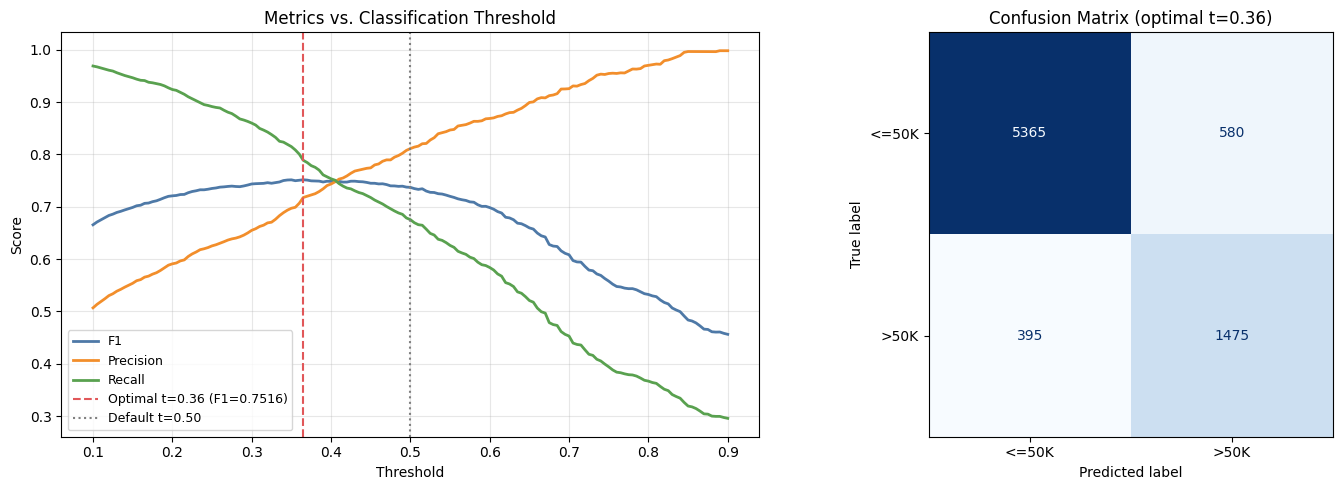

Optimal threshold : 0.365
F1 at optimal     : 0.7516
F1 at default 0.50: 0.7371
F1 improvement    : +0.0145


In [14]:
# 4b. Threshold selection -- sweep and maximise F1 on calibration holdout
best_model_name = 'HistGradientBoosting'
final_cal_model = calibrated_models[best_model_name]
proba_cal       = final_cal_model.predict_proba(X_cal)[:, 1]

thresholds     = np.linspace(0.10, 0.90, 161)
f1_by_thresh   = [f1_score(y_cal, (proba_cal >= t).astype(int), zero_division=0) for t in thresholds]
prec_by_thresh = [precision_score(y_cal, (proba_cal >= t).astype(int), zero_division=0) for t in thresholds]
rec_by_thresh  = [recall_score(y_cal, (proba_cal >= t).astype(int), zero_division=0) for t in thresholds]

best_thresh_idx = int(np.argmax(f1_by_thresh))
best_threshold  = thresholds[best_thresh_idx]
best_f1_thresh  = f1_by_thresh[best_thresh_idx]
default_f1      = f1_score(y_cal, (proba_cal >= 0.5).astype(int), zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thresholds, f1_by_thresh,   lw=2, color='#4e79a7', label='F1')
axes[0].plot(thresholds, prec_by_thresh, lw=2, color='#f28e2b', label='Precision')
axes[0].plot(thresholds, rec_by_thresh,  lw=2, color='#59a14f', label='Recall')
axes[0].axvline(best_threshold, color='#e15759', linestyle='--',
                label=f'Optimal t={best_threshold:.2f} (F1={best_f1_thresh:.4f})')
axes[0].axvline(0.5, color='grey', linestyle=':', label='Default t=0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs. Classification Threshold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

y_pred_opt = (proba_cal >= best_threshold).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_cal, y_pred_opt),
                       display_labels=['<=50K', '>50K']).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title(f'Confusion Matrix (optimal t={best_threshold:.2f})')
plt.tight_layout(); plt.show()

print(f'Optimal threshold : {best_threshold:.3f}')
print(f'F1 at optimal     : {best_f1_thresh:.4f}')
print(f'F1 at default 0.50: {default_f1:.4f}')
print(f'F1 improvement    : {best_f1_thresh - default_f1:+.4f}')

---
## Task 5 — Final Evaluation & Save Artifact

Hold-out test set touched **only here** — first and only time since Day 1.

In [15]:
proba_test      = final_cal_model.predict_proba(X_test_raw)[:, 1]
y_pred_opt_test = (proba_test >= best_threshold).astype(int)
y_pred_default  = (proba_test >= 0.5).astype(int)

rows = []
for label, y_pred in [('Optimal threshold', y_pred_opt_test), ('Default (0.50)', y_pred_default)]:
    rows.append({
        'Setting'  : label,
        'Threshold': round(best_threshold, 3) if 'Optimal' in label else 0.5,
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'ROC AUC'  : round(roc_auc_score(y_test, proba_test), 4),
        'Brier'    : round(brier_score_loss(y_test, proba_test), 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Setting')
print('=== Final Hold-Out Test Set Metrics ===')
print(metrics_df.to_string())
print('\nClassification Report (optimal threshold):')
print(classification_report(y_test, y_pred_opt_test, target_names=['<=50K', '>50K']))

=== Final Hold-Out Test Set Metrics ===
                   Threshold      F1  Precision  Recall  Accuracy  ROC AUC   Brier
Setting                                                                           
Optimal threshold      0.365  0.7306     0.7056  0.7575    0.8663   0.9299  0.0868
Default (0.50)         0.500  0.7113     0.7928  0.6450    0.8747   0.9299  0.0868

Classification Report (optimal threshold):
              precision    recall  f1-score   support

       <=50K       0.92      0.90      0.91      7431
        >50K       0.71      0.76      0.73      2338

    accuracy                           0.87      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.87      0.87      9769



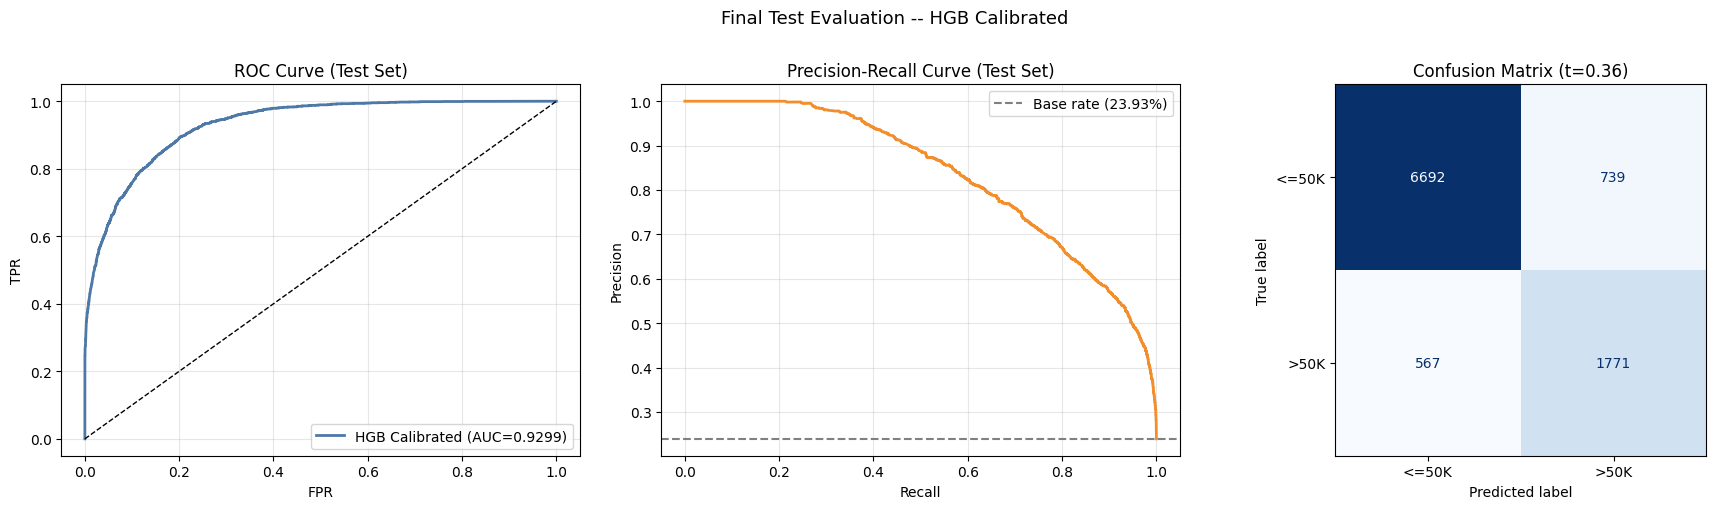

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, color='#4e79a7', lw=2,
             label=f'HGB Calibrated (AUC={roc_auc_score(y_test, proba_test):.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (Test Set)'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, color='#f28e2b', lw=2)
axes[1].axhline(y_test.mean(), color='grey', linestyle='--',
                label=f'Base rate ({y_test.mean():.2%})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set)')
axes[1].legend(); axes[1].grid(alpha=0.3)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_opt_test),
                       display_labels=['<=50K', '>50K']).plot(
    ax=axes[2], colorbar=False, cmap='Blues'
)
axes[2].set_title(f'Confusion Matrix (t={best_threshold:.2f})')
plt.suptitle('Final Test Evaluation -- HGB Calibrated', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [17]:
save_dir = r'd:\Netixsol_Internship\netixsol_internship\Week-4\day-4'
os.makedirs(save_dir, exist_ok=True)
pipeline_path = os.path.join(save_dir, 'adult_income_pipeline.joblib')

artifact = {
    'pipeline'          : final_cal_model,
    'optimal_threshold' : best_threshold,
    'best_params'       : hgb_search.best_params_,
    'final_test_metrics': metrics_df.to_dict(),
    'library_versions'  : {
        'sklearn': sklearn.__version__,
        'pandas' : pd.__version__,
        'numpy'  : np.__version__,
        'scipy'  : scipy.__version__,
        'joblib' : joblib.__version__,
    }
}
joblib.dump(artifact, pipeline_path)
print(f'Pipeline saved : {pipeline_path}')
print(f'File size      : {os.path.getsize(pipeline_path)/1024:.1f} KB')

print('''
=== How to Load and Run Inference ===

import joblib
artifact  = joblib.load('adult_income_pipeline.joblib')
pipeline  = artifact['pipeline']           # CalibratedClassifierCV full pipeline
threshold = artifact['optimal_threshold']  # F1-maximising threshold

proba  = pipeline.predict_proba(X_new)[:, 1]  # P(>50K)
y_pred = (proba >= threshold).astype(int)       # 0=<=50K, 1=>50K

Note: Pass raw Adult-format DataFrame -- feature engineering,
imputation, scaling and encoding happen inside the pipeline.
''')

Pipeline saved : d:\Netixsol_Internship\netixsol_internship\Week-4\day-4\adult_income_pipeline.joblib
File size      : 2367.7 KB

=== How to Load and Run Inference ===

import joblib
artifact  = joblib.load('adult_income_pipeline.joblib')
pipeline  = artifact['pipeline']           # CalibratedClassifierCV full pipeline
threshold = artifact['optimal_threshold']  # F1-maximising threshold

proba  = pipeline.predict_proba(X_new)[:, 1]  # P(>50K)
y_pred = (proba >= threshold).astype(int)       # 0=<=50K, 1=>50K

Note: Pass raw Adult-format DataFrame -- feature engineering,
imputation, scaling and encoding happen inside the pipeline.



In [18]:
print('=' * 60)
print('FINAL TUNING SUMMARY')
print('=' * 60)
print(f'\nBest model: HistGradientBoosting (isotonic-calibrated)')
print(f'Optimal threshold: {best_threshold:.3f}')
print(f'\nBest HGB hyperparameters:')
for k, v in hgb_search.best_params_.items():
    print(f'  {k:40s}: {v}')
print(f'\nFinal test metrics (threshold={best_threshold:.3f}):')
print(f'  F1        : {f1_score(y_test, y_pred_opt_test, zero_division=0):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_opt_test, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_opt_test, zero_division=0):.4f}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_opt_test):.4f}')
print(f'  ROC AUC   : {roc_auc_score(y_test, proba_test):.4f}')
print(f'  Brier     : {brier_score_loss(y_test, proba_test):.4f}')
print("""
Production behaviour:
  1. Input : raw Adult-format DataFrame (no preprocessing needed)
  2. Output: 0/1 binary via optimal probability threshold
  3. Latency: <1ms per row on CPU
  4. Monitor: Brier score (alert if drift >0.01) and F1 (alert if drop >0.03)
  5. Retrain trigger: positive-class base rate shifts >5pp from 24%
""")

FINAL TUNING SUMMARY

Best model: HistGradientBoosting (isotonic-calibrated)
Optimal threshold: 0.365

Best HGB hyperparameters:
  classifier__class_weight                : balanced
  classifier__l2_regularization           : 0.7261414516028828
  classifier__learning_rate               : 0.1035041273903399
  classifier__max_iter                    : 120
  classifier__max_leaf_nodes              : 43
  classifier__min_samples_leaf            : 19

Final test metrics (threshold=0.365):
  F1        : 0.7306
  Precision : 0.7056
  Recall    : 0.7575
  Accuracy  : 0.8663
  ROC AUC   : 0.9299
  Brier     : 0.0868

Production behaviour:
  1. Input : raw Adult-format DataFrame (no preprocessing needed)
  2. Output: 0/1 binary via optimal probability threshold
  3. Latency: <1ms per row on CPU
  4. Monitor: Brier score (alert if drift >0.01) and F1 (alert if drop >0.03)
  5. Retrain trigger: positive-class base rate shifts >5pp from 24%

